In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Exploration des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

#Chargement du data set
df = pd.read_csv("ai_impact_jobs_2010_2025.csv")
print ( df . head () )
print (" Shape :", df . shape )
print ( df . info () ) #informaion sur les colonnes





   job_id  year country         region       city          company_name  \
0       1  2018  Brazil  South America     London  NextGen Technologies   
1       2  2015     UAE    Middle East  Singapore      Future Solutions   
2       3  2016   Nepal     South Asia     Sydney      Future Analytics   
3       4  2015   Spain         Europe    Nairobi   Global Technologies   
4       5  2014  Taiwan      East Asia     Sydney   Future Technologies   

  company_size       industry        job_title seniority_level  ai_mentioned  \
0        Small      Education   Policy Analyst            Lead          True   
1       Medium         Energy   Data Scientist       Executive         False   
2      Startup        Finance  Product Manager          Junior         False   
3        Large     Government   Data Scientist             Mid         False   
4        Small  Manufacturing      ML Engineer            Lead         False   

   ai_intensity_score                                        core_sk

#### Visualusation graphique

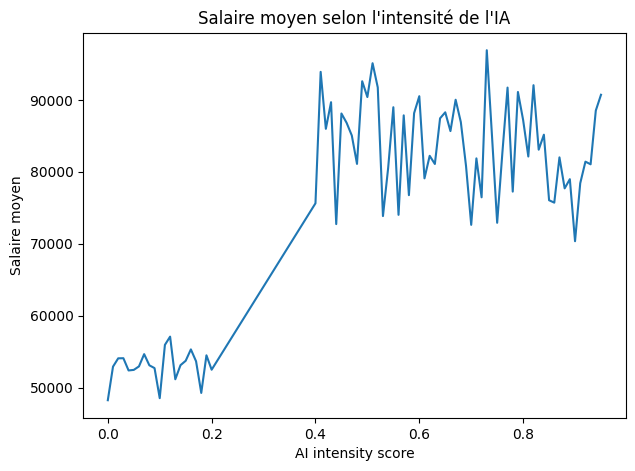

In [ ]:
plt.figure(figsize=(7,5))

df.groupby("ai_intensity_score")["salary_usd"].mean().plot()

plt.title("Salaire moyen selon l'intensité de l'IA")
plt.xlabel("AI intensity score")
plt.ylabel("Salaire moyen")

plt.show()

Le graphique montre une relation positive entre l’intensité de l’IA et le salaire moyen. Les salaires sont relativement faibles pour les faibles niveaux d’intensité de l’IA, puis augmentent progressivement lorsque l’intensité de l’IA augmente. Toutefois, pour les niveaux élevés, on observe une forte variabilité des salaires.

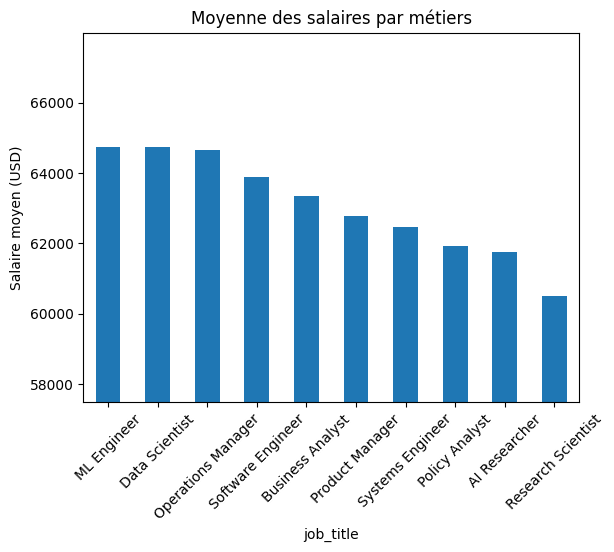

In [ ]:
top_jobs = df.groupby("job_title")["salary_usd"].mean().sort_values(ascending=False).head(10)

top_jobs.plot(kind="bar")

plt.title("Moyenne des salaires par métiers")
plt.ylabel("Salaire moyen (USD)")

plt.ylim(top_jobs.min()*0.95, top_jobs.max()*1.05)

plt.xticks(rotation=45)
plt.show()

Le graphique montre que les métiers liés à la data et à l’intelligence artificielle, tels que ML Engineer et Data Scientist, présentent les salaires moyens les plus élevés.Globalement, les écarts de salaires entre les différents métiers restent modérés, suggérant que la majorité des professions étudiées appartiennent à des domaines similaires en termes de rémunération.

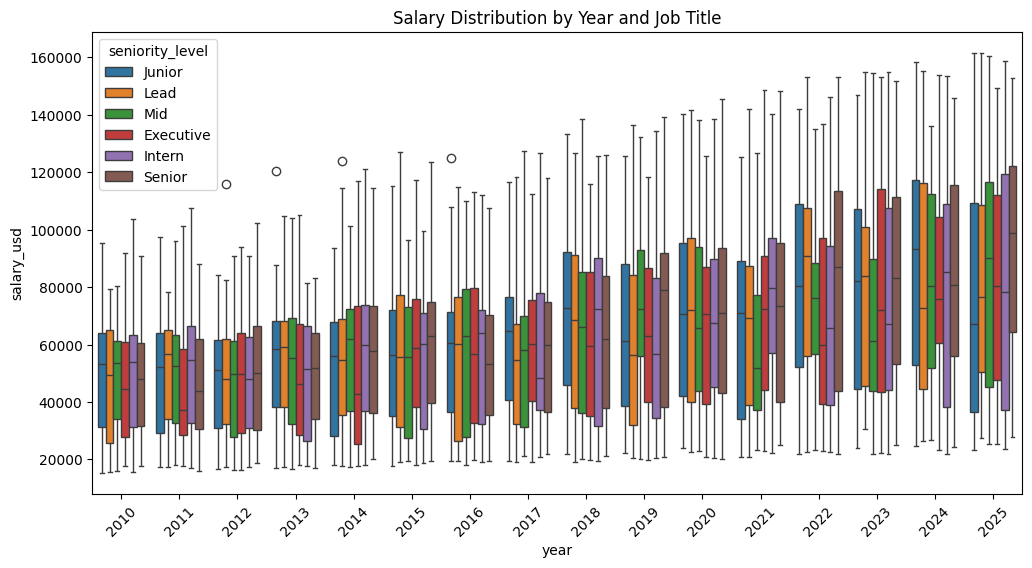

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="year",
    y="salary_usd",
    hue="seniority_level"
)

plt.xticks(rotation=45)
plt.title("Salary Distribution by Year and Job Title")
plt.show()

Nous observons que les salaires augmentent avec le temps et avec le niveau d’expérience, avec une dispersion plus importante pour les années récentes.

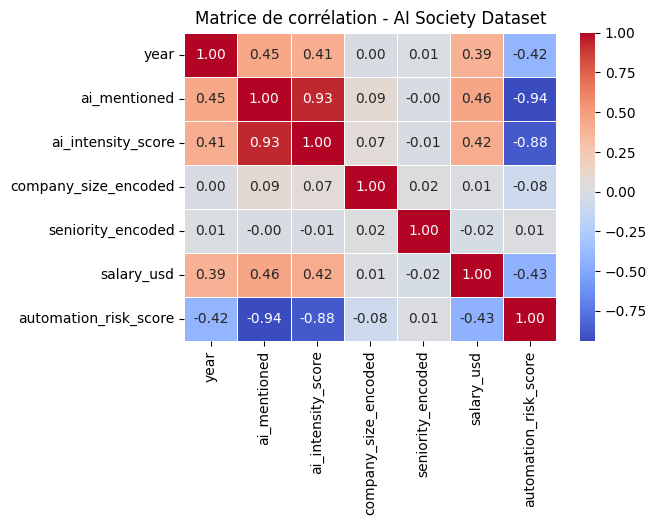

In [ ]:
#Matrice de corrélation
df["ai_mentioned"] = df["ai_mentioned"].astype(int)

size_mapping = {
    "Small": 1,
    "Medium": 2,
    "Large": 3
}
df["company_size_encoded"] = df["company_size"].map(size_mapping)

seniority_mapping = {
    "Junior": 1,
    "Mid": 2,
    "Senior": 3,
    "Lead": 4,
    "Executive": 5
}
df["seniority_encoded"] = df["seniority_level"].map(seniority_mapping)


colonnes_corr = [
    "year",
    "ai_mentioned",
    "ai_intensity_score",
    "company_size_encoded",
    "seniority_encoded",
    "salary_usd",
    "automation_risk_score"
]

df_corr = df[colonnes_corr]

corr_matrix = df_corr.corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation - AI Society Dataset")
plt.show()

L’analyse de la matrice de corrélation montre que le salaire est positivement corrélé avec les variables liées à l’intelligence artificielle, telles que l’intensité de l’IA et la mention de l’IA, ainsi qu’avec l’année, traduisant une augmentation des salaires dans le temps. En revanche, une corrélation négative est observée avec le risque d’automatisation, indiquant que les emplois moins automatisables sont mieux rémunérés. Les autres variables présentent des corrélations faibles, suggérant une relation non linéaire ou indirecte avec le salaire. Cette analyse est essentielle pour la prédiction, car elle permet d’identifier les variables les plus informatives et d’orienter le choix des modèles capables de capturer ces relations.

#### Notre problème consistera à prédire le salaire de plusieurs offres d'emplois à l'aide de plusieurs modéle en fonction de l'année où l'offre d'emploi a été diffusé, l'industrie, de la région, de la taille de la compagnie, du niveau d'expérience, de l'intensité de l'IA, du niveau du risque d'automatisation de l'offre et du nom de l'intitul" du poste correspondant.

In [ ]:
#On définit le problème à adapter

problem = {
    "type": "regression",
    "target": "salary_usd",
    "metrics": ["r2", "rmse", "mae"]
}

print ( problem )


{'type': 'regression', 'target': 'salary_usd', 'metrics': ['r2', 'rmse', 'mae']}


### Détection de fuite cible (target leakage)

Ceci est important pour détecter quelles variables sont les plus liées au salaire. Cela permet de repérer celles qui pourront être utiles pour la prédiction, mais aussi celles qu’il vaut mieux retirer afin d'éviter un modèle trompeur.


In [ ]:
target = "salary_usd"

if target in df.columns:

    tmp = df.select_dtypes(include="number").drop(columns=[target], errors="ignore")

    corr_to_target = df[tmp.columns].corrwith(df[target]).sort_values(
        key=lambda s: s.abs(),
        ascending=False
    )

    print(corr_to_target.head(10))

ai_mentioned             0.457716
automation_risk_score   -0.431737
ai_intensity_score       0.419280
year                     0.386976
salary_change            0.377662
seniority_encoded       -0.021343
company_size_encoded     0.009997
job_id                   0.007712
dtype: float64


On observe pour la sortie:

* automation_risk_score a une corrélation négative modérée avec le salaire ce qui signifie que plus
le risque d'automatisation est élevé plus le salaire tend à diminuer. Donc les emplois facilement automatisables par l'intelligenre artificiel sont souvent moins bien payés.

* ai_intensité_score : on observe une corrélation positive modérée, plus l’utilisation de l’IA est élevée dans le travail, plus le salaire tend à augmenter. Cela suggère que les métiers liés à l’IA sont mieux rémunérés dans notre data_set.

* L'année a une corrélation positive avec le salaire : les salaires augmentent avec le temps.

* Job_id: l'id de l'offre n'a aucune influence sur le salaire, la corrélation est quasi nulle

* Salary change : corrélation positive assez forte, celà peut venir du fait que salary_change est calculé à partir du salaire.

Donc pour la prédiction, nous n'allons pas utiliser salary_change, id_job


### Methode IQR

In [ ]:
Q1 = df["salary_usd"].quantile(0.25)
Q3 = df["salary_usd"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)

print(upper)

outliers = df[(df["salary_usd"] < lower) | (df["salary_usd"] > upper)]

print("Nombre d'outliers :", len(outliers))
print("Pourcentage :", len(outliers) / len(df) * 100)
print(outliers[["salary_usd", "job_title", "region", "industry","seniority_level","ai_intensity_score"]])

-31278.875
149666.125
Nombre d'outliers : 30
Pourcentage : 0.6
      salary_usd           job_title         region       industry  \
259       157355     Product Manager  North America        Finance   
334       152964         ML Engineer  North America         Retail   
355       154969  Research Scientist  North America           Tech   
412       158734       AI Researcher  North America           Tech   
604       151316    Business Analyst  North America     Healthcare   
639       154995    Business Analyst  North America     Government   
738       153069  Operations Manager  North America  Manufacturing   
781       153397      Policy Analyst  North America           Tech   
952       151557    Business Analyst  North America         Energy   
1047      152987  Operations Manager  North America  Manufacturing   
1220      152307   Software Engineer  North America           Tech   
1555      160586  Operations Manager  North America         Energy   
1590      151552      Data 

La méthode de l’IQR permet d’identifier les salaires atypiques en définissant une zone “normale” à partir des quartiles Q1 et Q3. La borne inférieure obtenue est négative. Ce n’est pas une erreur : cela vient du fait que la dispersion des salaires est importante, ce qui fait que l’intervalle théorique s’étend en dessous de 0, mais elle n’est pas pertinente ici car un salaire ne peut pas être négatif. Cela indique qu’il n’y a pas de valeurs anormalement basses.

L’analyse se concentre donc sur la borne supérieure afin d’identifier les salaires les plus élevés. Les valeurs aberrantes ont été identifiées à l’aide de cette méthode et correspondent pour la plus part à des offres à forte intensité en IA, caractérisés par des niveaux de rémunération significativement plus élevés que la moyenne.
Toutefois, ces valeurs représentent une très faible proportion du dataset (environ 0,6 %), ce qui limite leur impact sur la modélisation.

# Test

Un échantillon de test de 20 % est utilisé afin d’évaluer les performances des modèles et de comparer leur pertinence. Une validation croisée à 5 plis est également mise en place afin d’obtenir une estimation plus robuste.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd

# Variable cible
y = df["salary_usd"]

# Variables explicatives
X = df[[
    "year",
    "region",
    "industry",
    "automation_risk_score",
    "company_size",
    "seniority_level",
    "ai_intensity_score",
    "job_title"
]]
# Encodage des variables qualitatives
X = pd.get_dummies(X)

# Découpage train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## *Modèle* 1: Régression linéaire

La régression linéaire est un modèle prédictif qui établit une relation linéaire entre une variable dépendante et plusieurs variables explicatives. Elle consiste à estimer des coefficients en minimisant la somme des carrés des erreurs entre les valeurs observées et les valeurs prédites sous certains hypothèse. Une fois les coefficients estimés, la prédiction est obtenue en combinant linéairement les variables explicatives.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


model_lr = LinearRegression()

# Entraînement
model_lr.fit(X_train, y_train)

# Prédiction
y_pred_lr = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\nÉvaluation finale sur le test")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)


Évaluation finale sur le test
RMSE: 9496.938006651528
MAE: 7406.0019355824015
R2: 0.913484298223104


Le RMSE (Root Mean Squared Error) mesure l’erreur moyenne des prédictions, en pénalisant davantage les grandes erreurs. Plus il est faible, meilleur est le modèle.

Le MAE (Mean Absolute Error) correspond à l’erreur moyenne en valeur absolue, exprimée ici en dollars.

Le R² mesure la capacité du modèle à expliquer la variabilité des données.

Dans le cas de la régression linéaire, le RMSE est de 9 496,94, ce qui signifie que le modèle fait une erreur d’environ 9 496 dollars sur la prédiction du salaire.

Le MAE est d’environ 7 400 dollars, ce qui indique que le modèle se trompe en moyenne de 7 400 dollars par prédiction.

Le R² est de 0,91, ce qui montre que le modèle explique environ 91 % de la variabilité du salaire.

Globalement, le modèle présente de bonnes performances et constitue une base pertinente pour la prédiction.

### Validation croisée pour la regression linéaire

In [ ]:
# Validation croisée

scores = cross_val_score(model_lr, X, y, cv=5, scoring="r2")

print("Scores R2 (validation croisée) :", scores)
print("Score moyen CV :", scores.mean())



Scores R2 (validation croisée) : [0.9076388  0.90923966 0.91523879 0.91616056 0.90923839]
Score moyen CV : 0.9115032386442763


La validation croisée donne des scores R² compris entre 0,90 et 0,91, avec une moyenne d’environ 0,91. Ces résultats sont très proches entre les différents plis, ce qui montre que le modèle est stable et ne dépend pas fortement du découpage des données. Le modèle généralise donc bien et ses performances sont cohérentes avec celles observées sur le jeu de test.

### Visualisation graphique


/tmp/ipykernel_2688/2978033087.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


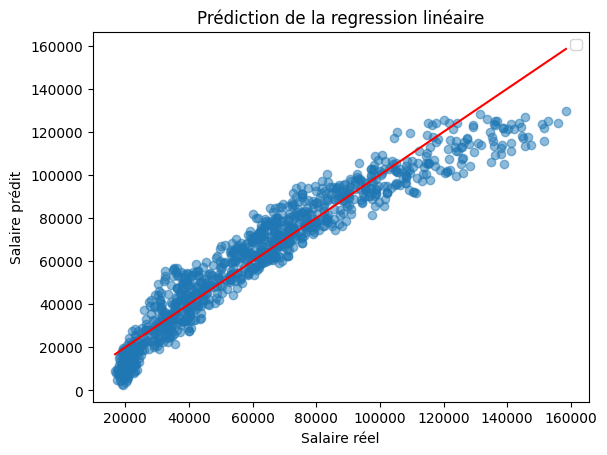

In [ ]:
plt.figure()

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.legend()
plt.xlabel("Salaire réel")
plt.ylabel("Salaire prédit")
plt.title("Prédiction de la regression linéaire")

plt.show()

Le graphique compare les salaires réels et les salaires prédits par le modèle. Les points sont globalement alignés autour de la diagonale, ce qui indique que le modèle réalise de bonnes prédictions.

Cependant, on observe une tendance à sous-estimer les salaires les plus élevés, ainsi qu’une dispersion plus importante pour ces valeurs. Cela montre que le modèle est moins précis sur les extrêmes.

###Cherchons les variables qui influencent le plus le salaire pour le modèle de la régression linéaire

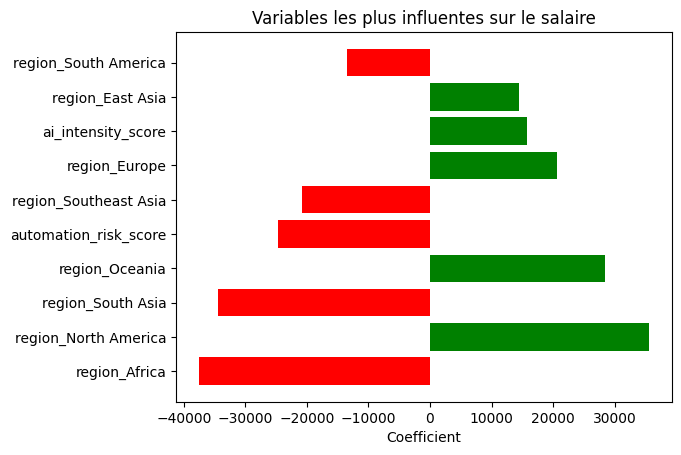

In [ ]:
import matplotlib.pyplot as plt

# Importance des variables (régression linéaire)
importance = pd.DataFrame({
    "variable": X.columns,
    "coefficient": model_lr.coef_
})

# Valeur absolue pour mesurer l’importance
importance["abs_coef"] = importance["coefficient"].abs()

# Trier du plus important au moins important
importance = importance.sort_values(by="abs_coef", ascending=False)

top = importance.head(10)

colors = ["green" if x > 0 else "red" for x in top["coefficient"]]

plt.barh(top["variable"], top["coefficient"], color=colors)
plt.title("Variables les plus influentes sur le salaire")
plt.xlabel("Coefficient")
plt.show()


Les résultats montrent que les variables les plus influentes sur le salaire sont principalement liées à la région, avec des écarts importants selon les zones géographiques. Certaines régions, comme l’Amérique du Nord et l’Océanie, sont associées à des salaires plus élevés, tandis que d’autres sont associées à des niveaux de rémunération plus faibles.

Par ailleurs, l’intensité de l’IA a un effet positif sur le salaire, ce qui suggère que les métiers fortement liés à l’IA sont mieux rémunérés. À l’inverse, le risque d’automatisation a un effet négatif, indiquant que les emplois plus automatisables tendent à être moins bien payés.

### Métriques d’erreur: régression linéaire
Le R² obtenu est élevé (0,91), ce qui indique que le modèle explique bien la variabilité globale des salaires.

Cependant, cette métrique ne permet pas à elle seule de repérer d’éventuelles erreurs localisées. Il est donc utile d’analyser plus précisément les erreurs du modèle.

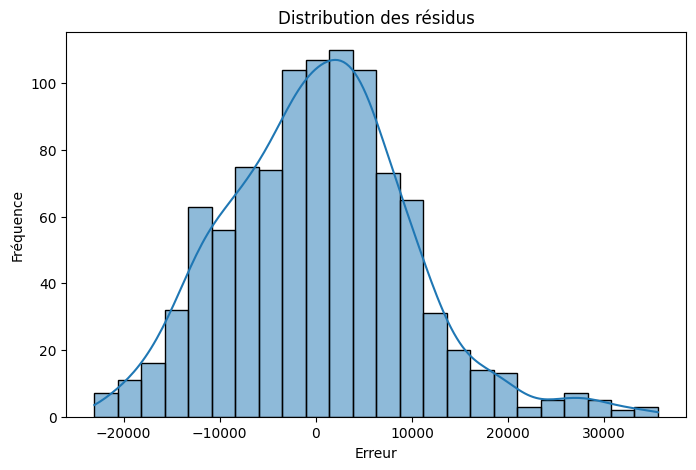

In [ ]:
# erreur = yréel - yprédit
residus = y_test - y_pred_lr

plt.figure(figsize=(8,5))
sns.histplot(residus, kde=True)
plt.title("Distribution des résidus")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()

La distribution des résidus est globalement centrée autour de zéro et présente une forme proche d’une loi normale, ce qui valide en partie les hypothèses du modèle de régression linéaire. Cependant, une asymétrie vers la droite est observée, indiquant que le modèle tend à sous-estimer les salaires les plus élevés.

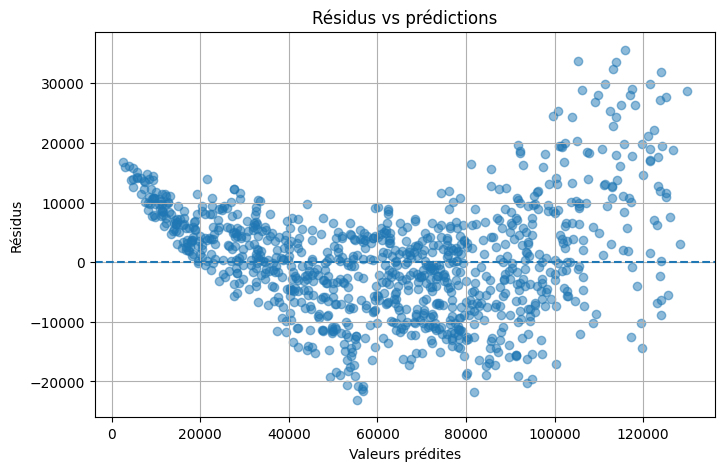

In [ ]:
#Avec ce graphique, on va vérifier
# si le modèle se trompe au hasard ou
#s’il se trompe d’une manière organisée
import matplotlib.pyplot as plt

residus = y_test - y_pred_lr

plt.figure(figsize=(8,5))
plt.scatter(y_pred_lr, residus, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs prédictions")
plt.grid(True)
plt.show()

Ce graphique montre que le modèle linéaire ne se trompe pas au hasard. Il a tendance à mal prédire certaines zones, surtout les salaires élevés.On observe une forme courbée, ce qui suggère que la relation entre les variables explicatives et le salaire n’est pas parfaitement linéaire et que les résidus augmentent pour les salaires élévés, le modèle est moins précis pour ces valeurs.

## *Modèle* 2: Gradient Boosting
Le Gradient Boosting Regressor est un modèle d’ensemble fondé sur une succession de petits arbres de décision.Le modèle construit les arbres les uns après les autres. Chaque nouvel arbre cherche à corriger les erreurs faites par les précédents. La prédiction finale est donc obtenue par une amélioration progressive de la prédiction initiale.

In [ ]:

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_gb = GradientBoostingRegressor(random_state=42)

model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("\n--- Évaluation finale ---")
print("RMSE:", rmse_gb)
print("MAE:", mae_gb)
print("R2:", r2_gb)


--- Évaluation finale ---
RMSE: 6395.021673470659
MAE: 4913.543776692184
R2: 0.9607705905696431


Le modèle de Gradient Boosting présente de très bonnes performances, avec un R² élevé (≈ 0,96), ce qui indique qu’il explique une grande partie de la variabilité du salaire. Les erreurs restent relativement faibles, avec un RMSE d’environ 6 400 dollars et un MAE d’environ 4 900 $, ce qui montre que les prédictions sont globalement précises.

Validation croisée pour le gradient boosting

In [ ]:
#Validation croisée
scores = cross_val_score(model_gb, X, y, cv=5, scoring="r2")

print("Scores R2 (CV) :", scores)
print("Score moyen CV :", scores.mean())

Scores R2 (CV) : [0.95693851 0.96054914 0.96175956 0.96192637 0.95970772]
Score moyen CV : 0.9601762595856693


La validation croisée donne des scores R² compris entre 0,95 et 0,96, avec une moyenne d’environ 0,96. Ces résultats sont très proches entre les différents plis, ce qui montre que le modèle est stable et ne dépend pas fortement du découpage des données.

### Visualisation graphique



/tmp/ipykernel_2688/2153954206.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


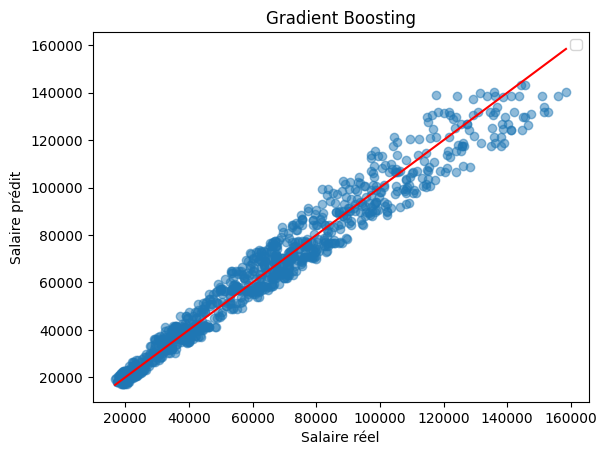

In [ ]:
plt.figure()

plt.scatter(y_test, y_pred_gb, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.legend()
plt.xlabel("Salaire réel")
plt.ylabel("Salaire prédit")
plt.title("Gradient Boosting")

plt.show()

Le graphique compare les salaires réels et les salaires prédits par le modèle. Les points sont globalement bien alignés autour de la diagonale, ce qui indique que le gradient boosting réalise de bonnes prédictions.

On observe une légère dispersion pour les salaires les plus élevés, mais elle reste limitée. Cela montre que le modèle garde une bonne précision même sur les valeurs extrêmes.

### Métriques d’erreur: gradient boosting




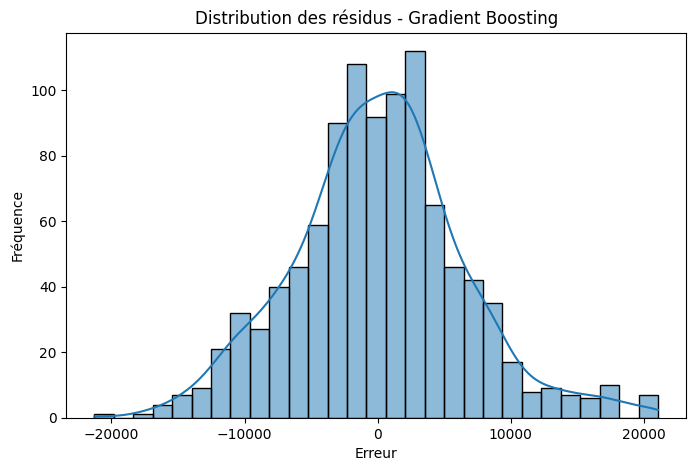

In [ ]:
residus_gb = y_test - y_pred_gb

plt.figure(figsize=(8,5))
sns.histplot(residus_gb, kde=True)
plt.title("Distribution des résidus - Gradient Boosting")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()


La distribution des résidus présente une forme globalement gaussienne et est centrée autour de zéro, ce qui indique l’absence de biais global dans les prédictions. La majorité des erreurs est concentrée autour de valeurs faibles, traduisant une bonne précision du modèle. Toutefois, la présence de quelques erreurs importantes montre que certaines observations restent difficiles à prédire.

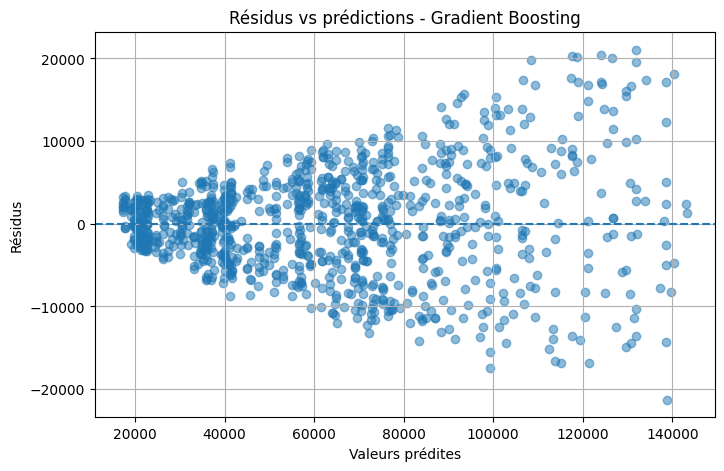

In [ ]:
# Résidus vs prédictions
plt.figure(figsize=(8,5))
plt.scatter(y_pred_gb, residus_gb, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs prédictions - Gradient Boosting")
plt.grid(True)
plt.show()

Le graphique des résidus en fonction des valeurs prédites montre que les erreurs sont globalement centrées autour de zéro, ce qui indique l’absence de biais global.On observe que le modèle est plutôt bon pour pour prédire les salaires pas trés elevés.Cependant, la dispersion des résidus augmente avec les valeurs prédites, suggérant que le modèle est moins précis pour les salaires élevés. La présence de certaines erreurs importantes indique également que certaines observations restent difficiles à prédire.

## *Modèle* 3: Random Forest

Le Random Forest Regressor est un modèle d’ensemble fondé sur une multitude d’arbres de décision. Chaque arbre est construit à partir d’un échantillon aléatoire des données et d’un sous-ensemble aléatoire de variables.

In [ ]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Évaluation finale ---")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)




--- Évaluation finale ---
RMSE: 6795.105116271793
MAE: 5139.03551
R2: 0.9557085306945817



Le modèle Random Forest présente de très bonnes performances, avec un R² élevé (≈ 0,96), ce qui indique qu’il explique une grande partie de la variabilité du salaire. Les erreurs restent relativement faibles, avec un RMSE d’environ 6 800 Dollars et un MAE d’environ 5 100 $, ce qui montre que les prédictions sont globalement précises.


### Validation croisée random forest

In [ ]:
scores = cross_val_score(model_rf, X, y, cv=5, scoring="r2")
print("Score R2 (CV) :", scores)
print("Score moyen CV :", scores.mean())

Score R2 (CV) : [0.95223741 0.95723061 0.95730409 0.95747909 0.95613754]
Score moyen CV : 0.9560777498889358


La validation croisée donne des scores R² compris entre 0,952 et 0,957, avec une moyenne d’environ 0,956. Les résultats sont proches entre les différents plis, ce qui montre que le modèle est stable et peu sensible au découpage des données.

###Importance des variables pour le modèle "random forest"

In [ ]:
# Importance des variables - Random Forest
importance_rf = pd.DataFrame({
    "variable": X_train.columns,
    "importance": model_rf.feature_importances_
})

importance_rf = importance_rf.sort_values(by="importance", ascending=False)

print(importance_rf.head(10))

                 variable  importance
10      region_South Asia    0.153388
3           region_Africa    0.150531
1   automation_risk_score    0.119852
11  region_Southeast Asia    0.105511
9    region_South America    0.103938
2      ai_intensity_score    0.100936
7    region_North America    0.087370
0                    year    0.055851
8          region_Oceania    0.030371
6      region_Middle East    0.028797


L’analyse des importances du modèle Random Forest montre que les variables les plus influentes sur le salaire sont principalement liées à la région, confirmant l’importance de la localisation géographique. Le risque d’automatisation et l’intensité de l’IA apparaissent également comme des facteurs clés, indiquant que les caractéristiques du métier jouent un rôle important. À l’inverse, certaines variables comme l’année ont une influence plus limitée.

###Visualisation graphique

/tmp/ipykernel_12772/3132248031.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


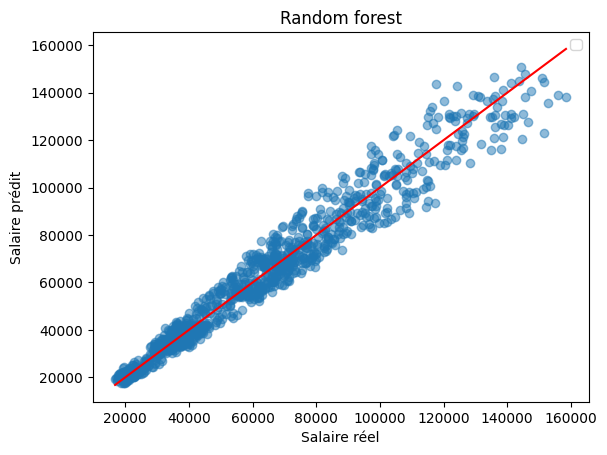

In [ ]:
plt.figure()

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.legend()
plt.xlabel("Salaire réel")
plt.ylabel("Salaire prédit")
plt.title("Random forest")

plt.show()

Le graphique compare les salaires réels et les salaires prédits par le modèle. Les points sont globalement bien alignés autour de la diagonale, ce qui indique que le random forest réalise de bonnes prédictions.

On observe toutefois une légère dispersion pour les salaires les plus élevés. Cela montre que le modèle reste précis dans l’ensemble, mais avec un peu plus d’écart sur les valeurs extrêmes.

### Métriques d’erreur: random forest

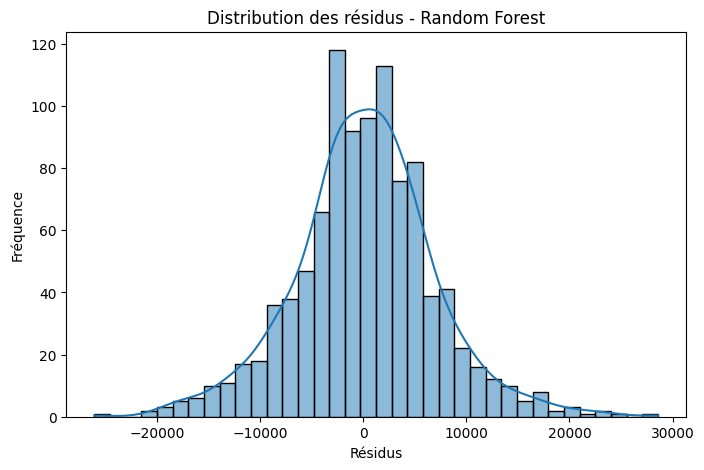

In [ ]:
residus_rf = y_test - y_pred_rf

plt.figure(figsize=(8,5))
sns.histplot(residus_rf, kde=True)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Distribution des résidus - Random Forest")
plt.show()


#### On s'aperçoit que la distribution des résidus est globalement centrée autour de zéro et présente une forme proche d’une loi normale, ce qui indique que les erreurs sont aléatoires et que le modèle ne présente pas de biais systématique. Toutefois, l’étendue importante des résidus et la présence de valeurs extrêmes montrent que certaines prédictions restent imprécises, notamment pour des observations atypiques. Le modèle est donc globalement performant, mais sa précision varie selon les individus.

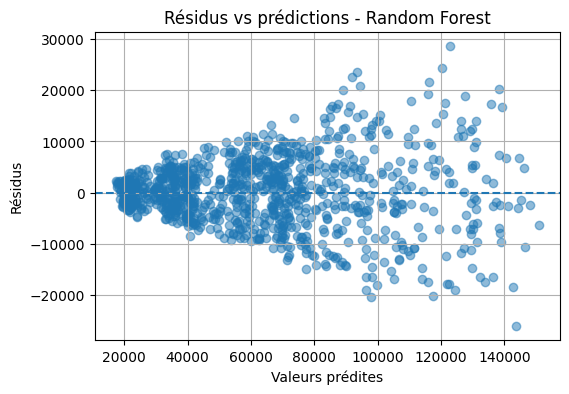

In [ ]:
#Graphique des résidus par rapport aux valeurs prédites
plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residus_rf, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs prédictions - Random Forest")
plt.grid(True)
plt.show()

#### Le graphique des résidus en fonction des valeurs prédites montre que les erreurs sont globalement centrées autour de zéro, indiquant l’absence de biais systématique du modèle Random Forest. Toutefois, on observe une augmentation de la dispersion des résidus pour les valeurs prédites élevées.Cela signifie que le modèle est moins précis pour les grandes valeurs. Enfin, la présence de valeurs extrêmes indique que certaines observations sont mal prédites.

## *Modèle* 4: KNN

Le modèle KNN (K-Nearest Neighbors) est une méthode non paramétrique qui consiste à prédire la valeur d’une observation en se basant sur les k observations les plus proches dans l’espace des variables. La prédiction est obtenue en calculant la moyenne des valeurs des voisins les plus proches. Ce modèle ne repose pas sur une phase d’apprentissage explicite, mais sur le calcul de distances entre observations.


In [ ]:

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


model_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)


mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("RMSE :", rmse_knn)
print("MAE :", mae_knn)
print("R2 :", r2_knn)

RMSE : 16609.88822120727
MAE : 12337.001799999998
R2 : 0.7353565506795872


Le RMSE est d’environ 16 610 dollars , ce qui indique que les erreurs de prédiction sont assez importantes. Le MAE est d’environ 12 337 $, ce qui signifie que le modèle se trompe en moyenne de plus de 12 000 dollars par prédiction. Le R² est de 0,74, ce qui montre que le modèle explique une partie de la variabilité du salaire, mais de manière encore limitée.

Globalement, les prédictions présentent des écarts importants, ce qui traduit une précision moyenne du modèle.

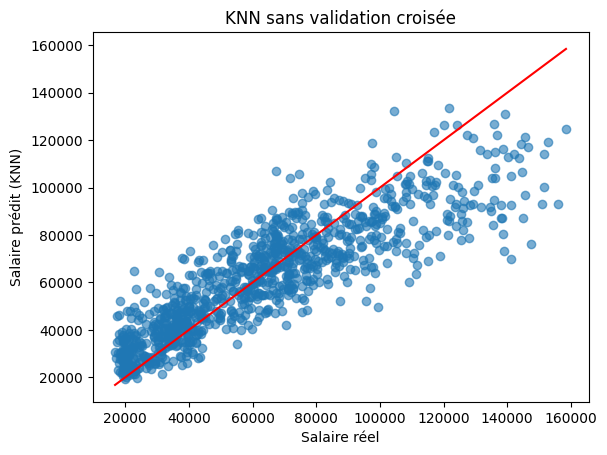

In [ ]:
# Graphique réel vs prédit
plt.figure()
plt.scatter(y_test, y_pred_knn, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Salaire réel")
plt.ylabel("Salaire prédit (KNN)")
plt.title("KNN sans validation croisée")
plt.show()

Le graphique compare les salaires réels et les salaires prédits par le modèle. Les points sont plus dispersés autour de la diagonale, ce qui montre que le KNN réalise des prédictions moins précises.

On observe des écarts plus importants, notamment pour les salaires élevés, ce qui indique que le modèle a des difficultés à bien estimer certaines valeurs. Globalement, les prédictions sont plus approximatives.

In [ ]:
#Validation croisée et choix du meilleur k
k_values = range(1, 21)
mean_scores = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    mean_scores.append(scores.mean())

    print(f"k = {k}")
    print("Scores R2 :", scores)
    print("Moyenne :", scores.mean())
    print("-" * 40)



k = 1
Scores R2 : [0.43805315 0.4728589  0.45463997 0.52985404 0.47685682]
Moyenne : 0.47445257500864846
----------------------------------------
k = 2
Scores R2 : [0.62280519 0.60576784 0.6019479  0.66292087 0.63083697]
Moyenne : 0.6248557560620387
----------------------------------------
k = 3
Scores R2 : [0.68856162 0.6703148  0.6564519  0.6961151  0.69353094]
Moyenne : 0.680994872386553
----------------------------------------
k = 4
Scores R2 : [0.71494674 0.68545995 0.68551652 0.71946804 0.70252081]
Moyenne : 0.7015824112147924
----------------------------------------
k = 5
Scores R2 : [0.71239183 0.70005016 0.70635923 0.72977327 0.72229104]
Moyenne : 0.7141731056806633
----------------------------------------
k = 6
Scores R2 : [0.72965958 0.70089654 0.71820648 0.73472639 0.73207252]
Moyenne : 0.7231123033517004
----------------------------------------
k = 7
Scores R2 : [0.73434604 0.7184168  0.72432864 0.73778613 0.72857058]
Moyenne : 0.7286896373341154
--------------------------

La validation croisée permet d’évaluer l’impact du paramètre k sur les performances du modèle KNN. On observe que pour de petites valeurs de k, les scores R² sont faibles, ce qui traduit un modèle peu performant et instable.

Lorsque k augmente, les scores s’améliorent progressivement, ce qui montre que le modèle gagne en stabilité et en capacité de généralisation. Les performances atteignent un maximum autour de k ≈ 14 ou 15, avec un R² moyen d’environ 0,77.

Au-delà de cette valeur, les performances commencent légèrement à diminuer, ce qui indique que le modèle devient trop lissé et perd en précision.

Choix du meilleur k

Meilleur k : 15
Meilleur score moyen en validation croisée : 0.7686415675918391
Résultats du KNN avec validation croisée :
Best k : 15
RMSE : 14670.073008046915
MAE : 11327.441666666668
R2 : 0.7935607468661848


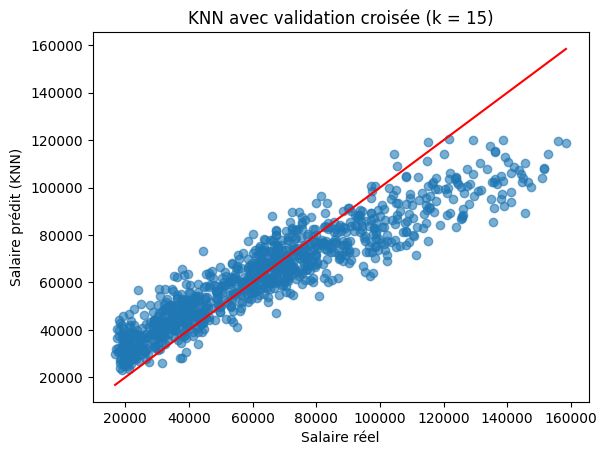

In [ ]:

best_k = k_values[np.argmax(mean_scores)]
best_score = max(mean_scores)

print("Meilleur k :", best_k)
print("Meilleur score moyen en validation croisée :", best_score)

# Modèle final avec le meilleur k
model_knn_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k))
])

# Entraînement du modèle final
model_knn_cv.fit(X_train, y_train)

# Prédictions sur le test
y_pred_knn_cv = model_knn_cv.predict(X_test)

# Évaluation finale
mse_knn_cv = mean_squared_error(y_test, y_pred_knn_cv)
rmse_knn_cv = np.sqrt(mse_knn_cv)
mae_knn_cv = mean_absolute_error(y_test, y_pred_knn_cv)
r2_knn_cv = r2_score(y_test, y_pred_knn_cv)

print("Résultats du KNN avec validation croisée :")
print("Best k :", best_k)
print("RMSE :", rmse_knn_cv)
print("MAE :", mae_knn_cv)
print("R2 :", r2_knn_cv)

# Graphique réel vs prédit
plt.figure()
plt.scatter(y_test, y_pred_knn_cv, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Salaire réel")
plt.ylabel("Salaire prédit (KNN)")
plt.title(f"KNN avec validation croisée (k = {best_k})")
plt.show()

On observe que le modèle (knn) a tendance à surestimer les faibles valeurs et à sous-estimer les valeurs élevées.

### Métriques d'erreur: KNN

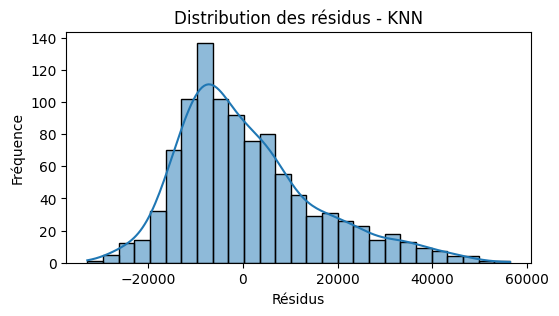

In [ ]:
residus_knn = y_test - y_pred_knn_cv
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as stats

plt.figure(figsize=(6,3))
sns.histplot(residus_knn, kde=True)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Distribution des résidus - KNN")
plt.show()

#### La distribution des résidus du modèle KNN n’est pas parfaitement symétrique et présente une asymétrie positive, indiquant une tendance du modèle à sous-estimer certaines valeurs élevées. Les résidus ne sont pas strictement centrés autour de zéro, ce qui suggère la présence d’un biais dans les prédictions. De plus, la dispersion importante et la présence de valeurs extrêmes montrent que certaines observations sont difficilement prédites, traduisant une variabilité élevée des erreurs.


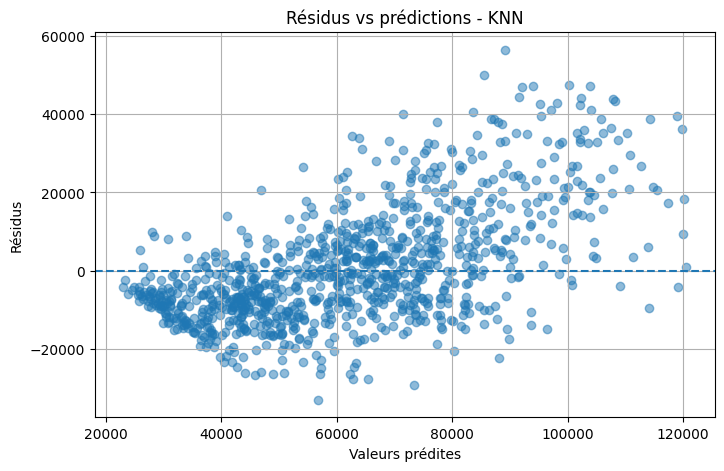

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred_knn_cv, residus_knn, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs prédictions - KNN")
plt.grid(True)
plt.show()

#### Le graphique des résidus en fonction des valeurs prédites pour le modèle KNN montre une augmentation de la dispersion des erreurs pour les valeurs élevées. De plus, les résidus présentent une structure non aléatoire, indiquant un biais du modèle : les petites valeurs sont plutôt surestimées tandis que les grandes valeurs sont sous-estimées. Enfin, la présence de valeurs extrêmes et la dispersion importante traduisent une variabilité élevée des erreurs et une précision limitée du modèle sur certaines observations.

## *Modéle* 5: Le Réseau de neurone

Le réseau de neurones est un modèle d’apprentissage supervisé composé de plusieurs couches de neurones artificiels. Chaque neurone effectue une combinaison linéaire des entrées suivie d’une fonction d’activation. Le modèle apprend en ajustant ses poids à l’aide de la descente de gradient et de la rétropropagation afin de minimiser l’erreur de prédiction. Il permet de modéliser des relations complexes et non linéaires entre les variables.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Pipeline : normalisation + modèle
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ))
])


# Entraînement final sur tout le train set
pipeline.fit(X_train, y_train)

# Prédictions sur le test set
y_pred_nn = pipeline.predict(X_test)

# Métriques
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("\n--- Évaluation finale ---")
print("RMSE:", rmse_nn)
print("MAE :", mae_nn)
print("R2  :", r2_nn)


--- Évaluation finale ---
RMSE: 7387.45927927981
MAE : 5458.3984367063695
R2  : 0.9476498501915073


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Le modèle de réseau de neurones présente de bonnes performances, avec un R² d’environ 0,95, indiquant qu’il explique une grande partie de la variabilité du salaire. Les erreurs restent modérées, avec un RMSE d’environ 7 400 et un MAE d’environ 5 500 $, ce qui montre que les prédictions sont globalement précises.

Un avertissement de convergence indique que le modèle n’a pas complètement convergé dans le nombre d’itérations fixé. Cependant, les performances obtenues restent satisfaisantes.


In [ ]:
# Cross-validation sur les données d'entraînement uniquement
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
print("Scores R2 (CV) :", cv_scores)
print("Score moyen CV :", cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Scores R2 (CV) : [0.94286236 0.94369694 0.94408604 0.94543066 0.94497937]
Score moyen CV : 0.9442110760288639


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Les scores de validation croisée sont tous très proches et très élevés, autour de 0,94. Ces résultats montrent que le modèle explique une grande part de la variabilité des salaires et présente une bonne stabilité d’un pli à l’autre. La faible dispersion des scores suggère une bonne capacité de généralisation sur les données d’entraînement.

Un avertissement de convergence apparaît toutefois, indiquant que le réseau de neurones n’a pas totalement convergé dans le nombre d’itérations fixé. Malgré cela, les performances obtenues restent satisfaisantes.

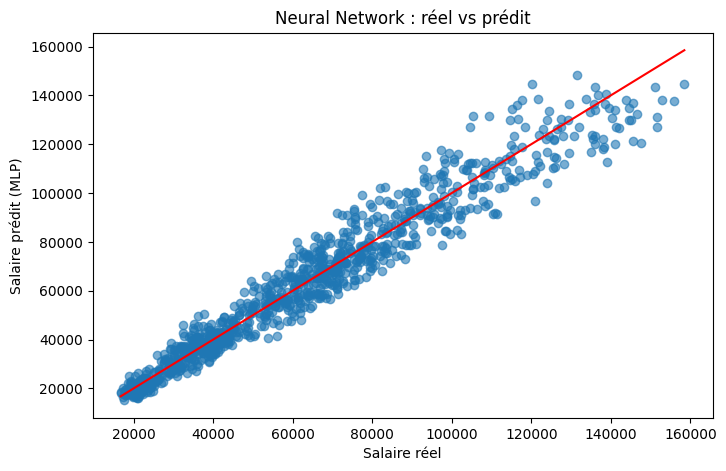

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_nn, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Salaire réel")
plt.ylabel("Salaire prédit (MLP)")
plt.title("Neural Network : réel vs prédit")
plt.show()

Le graphique des valeurs réelles versus les valeurs prédites montre que les prédictions du réseau de neurones sont globalement bien alignées avec la diagonale représentant la prédiction parfaite, ce qui traduit une bonne qualité du modèle. La majorité des points est proche de cette ligne, indiquant une forte corrélation entre les valeurs réelles et estimées. Toutefois, une dispersion plus importante est observée pour les salaires élevés, suggérant que le modèle est moins précis dans cette zone et tend à sous-estimer certaines valeurs élevées.

### Métriques d'erreur: réseau de neurones

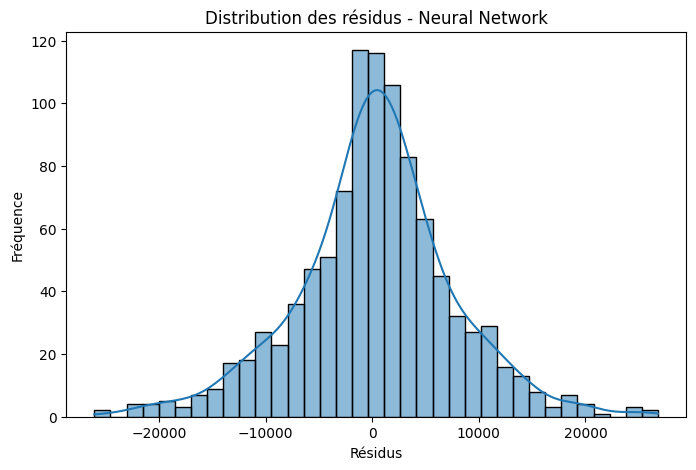

In [ ]:
residus_nn = y_test - y_pred_nn
plt.figure(figsize=(8,5))
sns.histplot(residus_nn, kde=True)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Distribution des résidus - Neural Network")
plt.show()

La distribution des résidus du réseau de neurones présente une forme proche d’une loi normale, centrée autour de zéro, indiquant l’absence de biais systématique et une bonne qualité globale des prédictions. La majorité des erreurs est concentrée autour de zéro, traduisant une bonne précision du modèle. Toutefois, la présence de valeurs extrêmes montre que certaines observations restent difficiles à prédire.

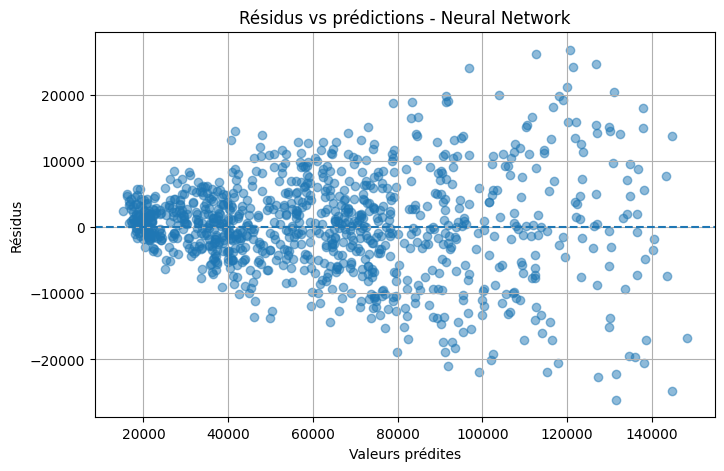

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred_nn, residus_nn, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs prédictions - Neural Network")
plt.grid(True)
plt.show()

L’analyse des résidus en fonction des valeurs prédites montre que les erreurs sont globalement centrées autour de zéro, traduisant l’absence de biais systématique du modèle. Toutefois, la dispersion des résidus augmente avec les valeurs prédites, cela signifie que le modèle est plus précis pour les salaires faibles que pour les salaires élevés. La présence de valeurs extrêmes suggère également que certaines observations restent difficiles à prédire.

## Comparaison des modèles de prédiction

Tableau de comparaison des valeurs

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "KNN", "Neural Network"],
    "RMSE": [rmse_lr, rmse_rf, rmse_gb, rmse_knn_cv, rmse_nn],
    "MAE": [mae_lr, mae_rf, mae_gb, mae_knn_cv, mae_nn],
    "R2": [r2_lr, r2_rf, r2_gb, r2_knn_cv, r2_nn]
})

results = results.sort_values(by="R2", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

            Model         RMSE          MAE       R2
Gradient Boosting  6395.021673  4913.543777 0.960771
    Random Forest  6795.105116  5139.035510 0.955709
   Neural Network  7387.459279  5458.398437 0.947650
Linear Regression  9496.938007  7406.001936 0.913484
              KNN 14670.073008 11327.441667 0.793561


L’étude comparative des modèles de régression montre que les méthodes basées sur les arbres de décision, en particulier le Gradient Boosting et le Random Forest, offrent les meilleures performances avec des coefficients de détermination supérieurs à 0,95 et des erreurs (RMSE et MAE) plus faibles. Ces modèles sont capables de capturer des relations non linéaires complexes entre les variables explicatives et le salaire.

Le réseau de neurones présente également de très bonnes performances, bien que légèrement inférieures à celles des modèles d’arbres, ce qui peut s’expliquer par la sensibilité aux paramètres et à l’optimisation.

La régression linéaire, bien que plus simple, montre des performances correctes mais limitées, suggérant que la relation entre les variables et le salaire n’est pas strictement linéaire. Enfin, le modèle KNN apparaît comme le moins performant, avec des erreurs élevées, indiquant qu’il est moins adapté à ce type de données.

L’analyse des résidus met en évidence un phénomène d’hétéroscédasticité, les erreurs augmentant avec les valeurs de salaire, ainsi que la présence de valeurs extrêmes, ce qui indique que les salaires élevés sont plus difficiles à prédire. Malgré cela, les modèles les plus performants restent globalement fiables et précis.